In [3]:
# """
# Create a grid of energy landscape subplots organized by seed parameters.
# Each subplot shows the energy landscape for a specific seed network, with arrows
# indicating the path from seed parameters to minimum energy parameters.
# """

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from matplotlib.colors import Normalize
# from matplotlib import cm
# from pathlib import Path
# from typing import Dict, List, Tuple, Optional


# class SeedEnergyGridVisualizer:
#     """Visualize energy landscapes for multiple seeds in an organized grid."""
    
#     def __init__(self, 
#                  seed_params_path: Path,
#                  output_base_path: Path,
#                  eta_range: Tuple[float, float] = (-8, 3),
#                  gamma_range: Tuple[float, float] = (0, 1)):
#         """
#         Initialize the visualizer.
        
#         Args:
#             seed_params_path: Path to seed parameters file (.npy)
#             output_base_path: Base path where experiment outputs are stored
#             eta_range: Range of eta values for energy landscapes
#             gamma_range: Range of gamma values for energy landscapes
#         """
#         self.seed_params_path = seed_params_path
#         self.output_base_path = output_base_path
#         self.eta_range = eta_range
#         self.gamma_range = gamma_range
        
#         # Load seed parameters
#         self.seed_params = self._load_seed_params()
#         self.n_seeds = len(self.seed_params)
        
#         # Determine grid layout based on unique eta and gamma values
#         self._determine_grid_layout()
        
#     def _load_seed_params(self) -> np.ndarray:
#         """Load seed parameters from file."""
#         params = np.load(self.seed_params_path)
#         print(f"Loaded {len(params)} seed parameters")
#         return params
    
#     def _determine_grid_layout(self):
#         """Determine grid dimensions based on unique seed parameter values."""
#         unique_eta = np.unique(self.seed_params[:, 0])
#         unique_gamma = np.unique(self.seed_params[:, 1])
        
#         self.n_eta = len(unique_eta)
#         self.n_gamma = len(unique_gamma)
#         self.unique_eta = sorted(unique_eta)
#         self.unique_gamma = sorted(unique_gamma)
        
#         print(f"Grid layout: {self.n_eta} eta values × {self.n_gamma} gamma values")
#         print(f"Eta values: {self.unique_eta}")
#         print(f"Gamma values: {self.unique_gamma}")
        
#     def _get_grid_position(self, eta: float, gamma: float) -> Tuple[int, int]:
#         """Get grid position (row, col) for given eta and gamma values."""
#         eta_idx = self.unique_eta.index(eta)
#         gamma_idx = self.unique_gamma.index(gamma)
#         # Row is gamma (y-axis), column is eta (x-axis)
#         return gamma_idx, eta_idx
    
#     def _load_energy_data(self, seed_idx: int) -> Optional[Tuple[pd.DataFrame, Dict]]:
#         """
#         Load energy landscape data for a specific seed.
        
#         Args:
#             seed_idx: Seed index
            
#         Returns:
#             Tuple of (DataFrame with energy data, dict with minimum info) or None
#         """
#         # Construct path to the all_metrics CSV file
#         exp_name = f"10_serious_sweep_copy_idx_{seed_idx}"
#         csv_path = self.output_base_path / exp_name / f"all_metrics_for_{exp_name}.csv"
        
#         if not csv_path.exists():
#             print(f"⚠️ Data not found for seed {seed_idx}: {csv_path}")
#             return None
        
#         try:
#             df = pd.read_csv(csv_path)
            
#             # Find minimum energy
#             # Assuming there's an 'energy' or similar column - adjust as needed
#             energy_col = "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"  # Adjust this based on your actual column name
            
#             if energy_col not in df.columns:
#                 print(f"⚠️ Energy column '{energy_col}' not found in {csv_path}")
#                 return None
            
#             min_idx = df[energy_col].idxmin()
#             min_data = {
#                 'eta': df.loc[min_idx, 'eta'],
#                 'gamma': df.loc[min_idx, 'gamma'],
#                 'energy': df.loc[min_idx, energy_col]
#             }
            
#             return df, min_data
            
#         except Exception as e:
#             print(f"❌ Error loading data for seed {seed_idx}: {e}")
#             return None
    
#     def create_grid_visualization(self, 
#                                  figsize: Optional[Tuple[float, float]] = None,
#                                  cmap: str = 'hot',
#                                  arrow_color: str = 'cyan',
#                                  arrow_width: float = 2.0,
#                                  save_path: Optional[Path] = None):
#         """
#         Create the complete grid visualization.
        
#         Args:
#             figsize: Figure size (width, height). If None, calculated automatically
#             cmap: Colormap name
#             arrow_color: Color for arrows
#             arrow_width: Width of arrow lines
#             save_path: Path to save figure
#         """
#         # Calculate figure size if not provided
#         if figsize is None:
#             subplot_size = 3
#             figsize = (self.n_eta * subplot_size + 1, self.n_gamma * subplot_size + 0.5)
        
#         # Create figure and subplots
#         fig, axes = plt.subplots(self.n_gamma, self.n_eta, 
#                                 figsize=figsize,
#                                 squeeze=False,
#                                 constrained_layout=True)
        
#         # Track colorbar limits across all plots
#         all_energies = []
#         plot_data = {}
        
#         # First pass: load all data and determine color limits
#         print("\n📊 Loading energy data for all seeds...")
#         for seed_idx, (eta_seed, gamma_seed, _) in enumerate(self.seed_params):
#             result = self._load_energy_data(seed_idx)
#             if result is not None:
#                 df, min_data = result
#                 all_energies.extend(df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"].values)
#                 plot_data[seed_idx] = (df, min_data, eta_seed, gamma_seed)
        
#         if not all_energies:
#             print("❌ No data loaded. Cannot create visualization.")
#             return
        
#         vmin, vmax = np.percentile(all_energies, [1, 99])
#         norm = Normalize(vmin=vmin, vmax=vmax)
#         cmap_obj = cm.get_cmap(cmap)
        
#         # Second pass: create plots
#         print("\n🎨 Creating plots...")
#         for seed_idx, data in plot_data.items():
#             df, min_data, eta_seed, gamma_seed = data
            
#             # Get grid position
#             row, col = self._get_grid_position(eta_seed, gamma_seed)
#             ax = axes[row, col]
            
#             # Create grid from scattered points
#             grid_data, eta_edges, gamma_edges = self._create_grid_from_df(df)
            
#             # Plot energy landscape
#             extent = [eta_edges[0], eta_edges[-1], gamma_edges[0], gamma_edges[-1]]
#             im = ax.imshow(grid_data, origin='lower', extent=extent,
#                           aspect='auto', cmap=cmap_obj, norm=norm,
#                           interpolation='nearest')
            
#             # Mark seed position
#             ax.plot(eta_seed, gamma_seed, 'o', color='white', 
#                    markersize=8, markeredgecolor='black', markeredgewidth=1.5,
#                    label='Seed')
            
#             # Mark minimum position
#             ax.plot(min_data['eta'], min_data['gamma'], '*', 
#                    color='lime', markersize=12, markeredgecolor='black',
#                    markeredgewidth=1.5, label='Minimum')
            
#             # Draw arrow from seed to minimum
#             ax.annotate('', xy=(min_data['eta'], min_data['gamma']),
#                        xytext=(eta_seed, gamma_seed),
#                        arrowprops=dict(arrowstyle='->', color=arrow_color,
#                                      lw=arrow_width, alpha=0.8))
            
#             # Set title with seed parameters
#             ax.set_title(f'Seed {seed_idx}\nη={eta_seed:.1f}, γ={gamma_seed:.2f}',
#                         fontsize=9)
            
#             # Only show axis labels on edges
#             if col == 0:
#                 ax.set_ylabel('γ', fontsize=10)
#             else:
#                 ax.set_yticklabels([])
            
#             if row == self.n_gamma - 1:
#                 ax.set_xlabel('η', fontsize=10)
#             else:
#                 ax.set_xticklabels([])
            
#             ax.tick_params(labelsize=8)
        
#         # Hide empty subplots
#         for row in range(self.n_gamma):
#             for col in range(self.n_eta):
#                 if (row, col) not in [(self._get_grid_position(p[0], p[1])) 
#                                      for p in self.seed_params]:
#                     axes[row, col].axis('off')
        
#         # Add colorbar
#         cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_obj),
#                           ax=axes, orientation='horizontal',
#                           pad=0.02, aspect=40, shrink=0.8)
#         cbar.set_label('Energy (MaxCriteria)', fontsize=11)
#         cbar.ax.tick_params(labelsize=9)
        
#         # Add legend
#         handles = [
#             mpatches.Patch(color='white', label='○ Seed position'),
#             mpatches.Patch(color='lime', label='★ Energy minimum'),
#             mpatches.FancyArrow(0, 0, 1, 1, color=arrow_color, 
#                               label='Optimization path')
#         ]
#         fig.legend(handles=handles, loc='upper right', 
#                   bbox_to_anchor=(0.99, 0.99), fontsize=10)
        
#         # Save figure
#         if save_path:
#             plt.savefig(save_path, dpi=300, bbox_inches='tight')
#             print(f"\n✅ Saved figure to {save_path}")
        
#         return fig, axes
    
#     def _create_grid_from_df(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
#         """Create 2D grid from DataFrame with eta, gamma, and metric values."""
#         unique_eta = np.sort(df['eta'].unique())
#         unique_gamma = np.sort(df['gamma'].unique())
        
#         # Initialize grid with NaN
#         grid = np.full((len(unique_gamma), len(unique_eta)), np.nan)
        
#         # Fill grid
#         for _, row in df.iterrows():
#             eta_idx = np.where(unique_eta == row['eta'])[0][0]
#             gamma_idx = np.where(unique_gamma == row['gamma'])[0][0]
#             grid[gamma_idx, eta_idx] = row["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]
        
#         return grid, unique_eta, unique_gamma


# # Example usage
# if __name__ == "__main__":
#     # Set paths
#     seed_params_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/05_seeds_of_humans/seeds_density2_16_regions_params.npy")
#     output_base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset")
    
#     # Create visualizer
#     visualizer = SeedEnergyGridVisualizer(
#         seed_params_path=seed_params_path,
#         output_base_path=output_base_path,
#         eta_range=(-8, 3),
#         gamma_range=(0, 1)
#     )
    
#     # Create and save visualization
#     save_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots/plots") / "seed_energy_landscape_grid.pdf"
#     fig, axes = visualizer.create_grid_visualization(
#         cmap='hot',
#         arrow_color='cyan',
#         arrow_width=2.5,
#         save_path=save_path
#     )
#     plt.savefig(save_path) 
#     plt.show()

Loaded 160 seed parameters
Grid layout: 4 eta values × 4 gamma values
Eta values: [np.float64(-8.0), np.float64(-4.333333333333334), np.float64(-0.666666666666667), np.float64(3.0)]
Gamma values: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]

📊 Loading energy data for all seeds...
⚠️ Data not found for seed 6: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/10_serious_sweep_copy_idx_6/all_metrics_for_10_serious_sweep_copy_idx_6.csv
⚠️ Data not found for seed 7: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/10_serious_sweep_copy_idx_7/all_metrics_for_10_serious_sweep_copy_idx_7.csv
⚠️ Data not found for seed 8: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/10_serious_sweep_copy_idx_8/all_metrics_for_10_serious_sweep_copy_idx_8.csv
⚠️ Data not found for seed 9: /Users/adrian/Documents/01

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_97176/3147074890.py:213: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)



✅ Saved figure to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots/plots/seed_energy_landscape_grid.pdf


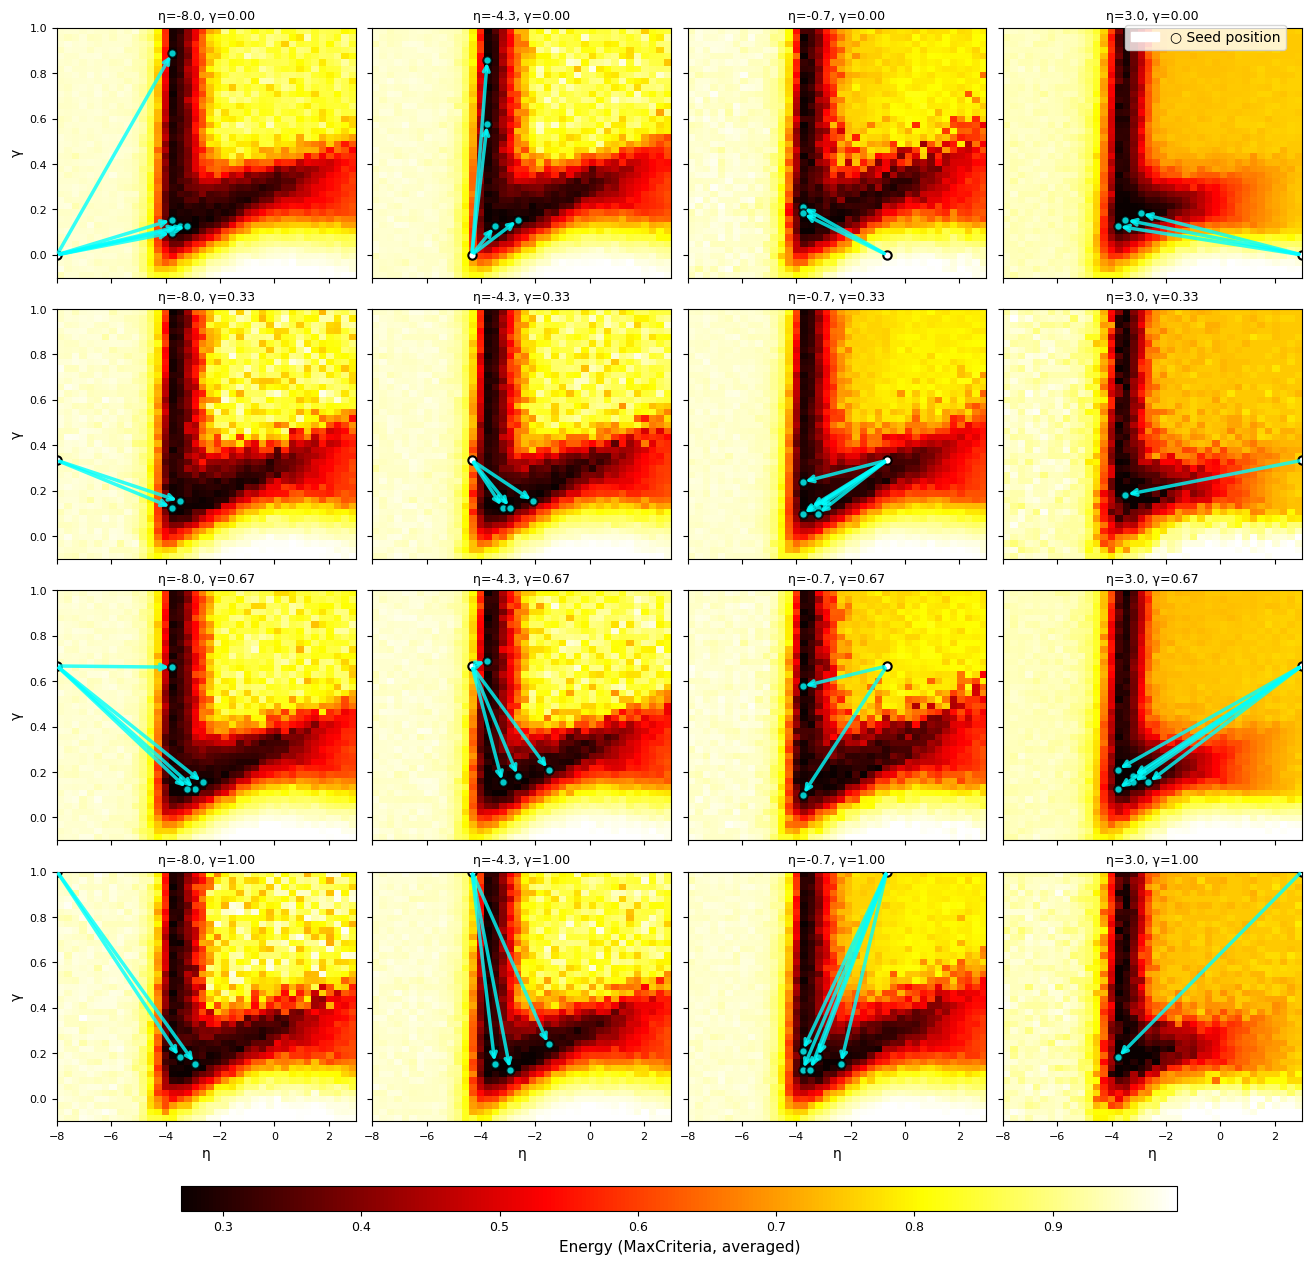

: 

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
"""
Create a grid of energy landscape subplots organized by seed parameters.
Each subplot shows the averaged energy landscape for all seeds with the same parameters,
with arrows indicating paths from seed parameters to ALL different minimum energy parameters.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib import cm
from pathlib import Path
from typing import Dict, List, Tuple, Optional


class SeedEnergyGridVisualizer:
    """Visualize energy landscapes for multiple seeds in an organized grid."""
    
    def __init__(self, 
                 seed_params_path: Path,
                 output_base_path: Path,
                 eta_range: Tuple[float, float] = (-8, 3),
                 gamma_range: Tuple[float, float] = (0, 1)):
        """
        Initialize the visualizer.
        
        Args:
            seed_params_path: Path to seed parameters file (.npy)
            output_base_path: Base path where experiment outputs are stored
            eta_range: Range of eta values for energy landscapes
            gamma_range: Range of gamma values for energy landscapes
        """
        self.seed_params_path = seed_params_path
        self.output_base_path = output_base_path
        self.eta_range = eta_range
        self.gamma_range = gamma_range
        
        # Load seed parameters
        self.seed_params = self._load_seed_params()
        self.n_seeds = len(self.seed_params)
        
        # Determine grid layout based on unique eta and gamma values
        self._determine_grid_layout()
        
    def _load_seed_params(self) -> np.ndarray:
        """Load seed parameters from file."""
        params = np.load(self.seed_params_path)
        print(f"Loaded {len(params)} seed parameters")
        return params
    
    def _determine_grid_layout(self):
        """Determine grid dimensions based on unique seed parameter values."""
        unique_eta = np.unique(self.seed_params[:, 0])
        unique_gamma = np.unique(self.seed_params[:, 1])
        
        self.n_eta = len(unique_eta)
        self.n_gamma = len(unique_gamma)
        self.unique_eta = sorted(unique_eta)
        self.unique_gamma = sorted(unique_gamma)
        
        print(f"Grid layout: {self.n_eta} eta values × {self.n_gamma} gamma values")
        print(f"Eta values: {self.unique_eta}")
        print(f"Gamma values: {self.unique_gamma}")
        
    def _get_grid_position(self, eta: float, gamma: float) -> Tuple[int, int]:
        """Get grid position (row, col) for given eta and gamma values."""
        eta_idx = self.unique_eta.index(eta)
        gamma_idx = self.unique_gamma.index(gamma)
        # Row is gamma (y-axis), column is eta (x-axis)
        return gamma_idx, eta_idx
    
    def _load_energy_data(self, seed_idx: int) -> Optional[Tuple[pd.DataFrame, Dict]]:
        """
        Load energy landscape data for a specific seed.
        
        Args:
            seed_idx: Seed index
            
        Returns:
            Tuple of (DataFrame with energy data, dict with minimum info) or None
        """
        # Construct path to the all_metrics CSV file
        exp_name = f"10_serious_sweep_copy_idx_{seed_idx}"
        csv_path = self.output_base_path / exp_name / f"all_metrics_for_{exp_name}.csv"
        
        if not csv_path.exists():
            print(f"⚠️ Data not found for seed {seed_idx}: {csv_path}")
            return None
        
        try:
            df = pd.read_csv(csv_path)
            
            # Find minimum energy
            energy_col = "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"
            
            if energy_col not in df.columns:
                print(f"⚠️ Energy column '{energy_col}' not found in {csv_path}")
                return None
            
            min_idx = df[energy_col].idxmin()
            min_data = {
                'eta': df.loc[min_idx, 'eta'],
                'gamma': df.loc[min_idx, 'gamma'],
                'energy': df.loc[min_idx, energy_col]
            }
            
            return df, min_data
            
        except Exception as e:
            print(f"❌ Error loading data for seed {seed_idx}: {e}")
            return None
    
    def _group_seeds_by_params(self) -> Dict[Tuple[float, float], List[int]]:
        """Group seed indices by their (eta, gamma) parameters."""
        groups = {}
        for seed_idx, (eta_seed, gamma_seed, _) in enumerate(self.seed_params):
            key = (eta_seed, gamma_seed)
            if key not in groups:
                groups[key] = []
            groups[key].append(seed_idx)
        return groups
    
    def _average_grids(self, dfs: List[pd.DataFrame]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Average multiple energy landscapes into a single grid."""
        # Get all unique eta and gamma values across all dataframes
        all_eta = np.concatenate([df['eta'].unique() for df in dfs])
        all_gamma = np.concatenate([df['gamma'].unique() for df in dfs])
        unique_eta = np.sort(np.unique(all_eta))
        unique_gamma = np.sort(np.unique(all_gamma))
        
        # Initialize grid for sum and count
        grid_sum = np.zeros((len(unique_gamma), len(unique_eta)))
        grid_count = np.zeros((len(unique_gamma), len(unique_eta)))
        
        energy_col = "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"
        
        # Accumulate values from all dataframes
        for df in dfs:
            for _, row in df.iterrows():
                eta_idx = np.where(unique_eta == row['eta'])[0][0]
                gamma_idx = np.where(unique_gamma == row['gamma'])[0][0]
                grid_sum[gamma_idx, eta_idx] += row[energy_col]
                grid_count[gamma_idx, eta_idx] += 1
        
        # Compute average (avoid division by zero)
        grid_avg = np.where(grid_count > 0, grid_sum / grid_count, np.nan)
        
        return grid_avg, unique_eta, unique_gamma
    
    def create_grid_visualization(self, 
                                 figsize: Optional[Tuple[float, float]] = None,
                                 cmap: str = 'hot',
                                 arrow_color: str = 'cyan',
                                 arrow_width: float = 2.0,
                                 save_path: Optional[Path] = None):
        """
        Create the complete grid visualization.
        
        Args:
            figsize: Figure size (width, height). If None, calculated automatically
            cmap: Colormap name
            arrow_color: Color for arrows
            arrow_width: Width of arrow lines
            save_path: Path to save figure
        """
        # Calculate figure size if not provided
        if figsize is None:
            subplot_size = 3
            figsize = (self.n_eta * subplot_size + 1, self.n_gamma * subplot_size + 0.5)
        
        # Create figure and subplots
        fig, axes = plt.subplots(self.n_gamma, self.n_eta, 
                                figsize=figsize,
                                squeeze=False,
                                constrained_layout=True)
        
        # Group seeds by their parameters
        seed_groups = self._group_seeds_by_params()
        
        # Track colorbar limits across all plots
        all_energies = []
        plot_data = {}
        
        # First pass: load all data and determine color limits
        print("\n📊 Loading energy data for all seeds...")
        for params, seed_indices in seed_groups.items():
            eta_seed, gamma_seed = params
            dfs = []
            min_data_list = []
            
            for seed_idx in seed_indices:
                result = self._load_energy_data(seed_idx)
                if result is not None:
                    df, min_data = result
                    dfs.append(df)
                    min_data_list.append(min_data)
                    all_energies.extend(df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"].values)
            
            if dfs:
                plot_data[params] = {
                    'dfs': dfs,
                    'min_data_list': min_data_list,
                    'n_seeds': len(dfs)
                }
        
        if not all_energies:
            print("❌ No data loaded. Cannot create visualization.")
            return
        
        vmin, vmax = np.percentile(all_energies, [1, 99])
        norm = Normalize(vmin=vmin, vmax=vmax)
        cmap_obj = cm.get_cmap(cmap)
        
        # Second pass: create plots
        print("\n🎨 Creating plots...")
        for params, data in plot_data.items():
            eta_seed, gamma_seed = params
            dfs = data['dfs']
            min_data_list = data['min_data_list']
            n_seeds = data['n_seeds']
            
            # Get grid position
            row, col = self._get_grid_position(eta_seed, gamma_seed)
            ax = axes[row, col]
            
            # Average the grids
            grid_data, eta_edges, gamma_edges = self._average_grids(dfs)
            
            # Plot energy landscape
            extent = [eta_edges[0], eta_edges[-1], gamma_edges[0], gamma_edges[-1]]
            im = ax.imshow(grid_data, origin='lower', extent=extent,
                          aspect='auto', cmap=cmap_obj, norm=norm,
                          interpolation='nearest')
            
            # Mark seed position
            ax.plot(eta_seed, gamma_seed, 'o', color='white', 
                   markersize=6, markeredgecolor='black', markeredgewidth=1.5,
                   label='Seed')
            
            # Get unique minimum positions
            unique_minima = {}
            for min_data in min_data_list:
                key = (round(min_data['eta'], 4), round(min_data['gamma'], 4))
                if key not in unique_minima:
                    unique_minima[key] = min_data
            
            # Draw arrows to ALL different minimum positions
            for min_data in unique_minima.values():
                # Mark minimum position
                ax.plot(min_data['eta'], min_data['gamma'], 'o', 
                       color=arrow_color, markersize=6, markeredgecolor='black',
                       markeredgewidth=1.5, alpha=0.8)
                
                # Draw arrow from seed to minimum
                ax.annotate('', xy=(min_data['eta'], min_data['gamma']),
                           xytext=(eta_seed, gamma_seed),
                           arrowprops=dict(arrowstyle='->', color=arrow_color,
                                         lw=arrow_width, alpha=0.8))
            
            # Set title with seed parameters and count
            ax.set_title(f'η={eta_seed:.1f}, γ={gamma_seed:.2f}', # \n(n={n_seeds})',
                        fontsize=9)
            
            # Only show axis labels on edges
            if col == 0:
                ax.set_ylabel('γ', fontsize=10)
            else:
                ax.set_yticklabels([])
            
            if row == self.n_gamma - 1:
                ax.set_xlabel('η', fontsize=10)
            else:
                ax.set_xticklabels([])
            
            ax.tick_params(labelsize=8)
        
        # Hide empty subplots
        for row in range(self.n_gamma):
            for col in range(self.n_eta):
                found = False
                for params in plot_data.keys():
                    if self._get_grid_position(params[0], params[1]) == (row, col):
                        found = True
                        break
                if not found:
                    axes[row, col].axis('off')
        
        # Add colorbar
        cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_obj),
                          ax=axes, orientation='horizontal',
                          pad=0.02, aspect=40, shrink=0.8)
        cbar.set_label('Energy (MaxCriteria, averaged)', fontsize=11)
        cbar.ax.tick_params(labelsize=9)
        
        # Add legend
        handles = [
            mpatches.Patch(color='white', label='○ Seed position'),
            # mpatches.Patch(color=arrow_color, label='o Energy minima'),
            # mpatches.FancyArrow(0, 0, 1, 1, color=arrow_color, 
            #                   label='→ Simulated annealing')
        ]
        fig.legend(handles=handles, loc='upper right', 
                  bbox_to_anchor=(0.99, 0.99), fontsize=10)
        
        # Save figure
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\n✅ Saved figure to {save_path}")
        
        return fig, axes


# Example usage
# if __name__ == "__main__":
# Set paths
seed_params_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/05_seeds_of_humans/seeds_density2_16_regions_params.npy")
output_base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset")

# Create visualizer
visualizer = SeedEnergyGridVisualizer(
    seed_params_path=seed_params_path,
    output_base_path=output_base_path,
    eta_range=(-8, 3),
    gamma_range=(0, 1)
)

# Create and save visualization
save_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots/plots") / "seed_energy_landscape_grid.pdf"
fig, axes = visualizer.create_grid_visualization(
    cmap='hot',
    arrow_color='cyan',
    arrow_width=2.5,
    save_path=save_path
)
plt.show()